# Quick-look simulations

This notebook can be used to have a quicklook at the that product for the simulations. Note that the `LightCurve` class used to analyse the data assumes a identical structure of the data products as they are delivered on the KU Leuven FTP server.

### Setup notebook

In [89]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [132]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Load light curves for one star

In [133]:
# Load all data for a single star
sims = "/lhome/nicholas/software/workdir/wp167/data_smbh"
idir = f"{sims}/000000001"
lcs = LightCurve(idir, mode="multi")
# To fetch a specific light curve, use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [22]:
# Unzip all compressed files for the same star
# lcs.unpack()

In [171]:
# Fetch all feather filenames
filenames = lcs.files("hdf5")
filenames[0]

'/lhome/nicholas/software/workdir/wp167/data_smbh/000000001/000000001_Ncam1.1_Q4.hdf5'

## Test reduction

In [182]:
# Fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,time,flux
0,23328018.75,2208.156250
1,23328618.75,2321.820312
2,23329218.75,2276.218750
3,23329818.75,2187.109375
4,23330418.75,2504.246094


<IPython.core.display.Javascript object>


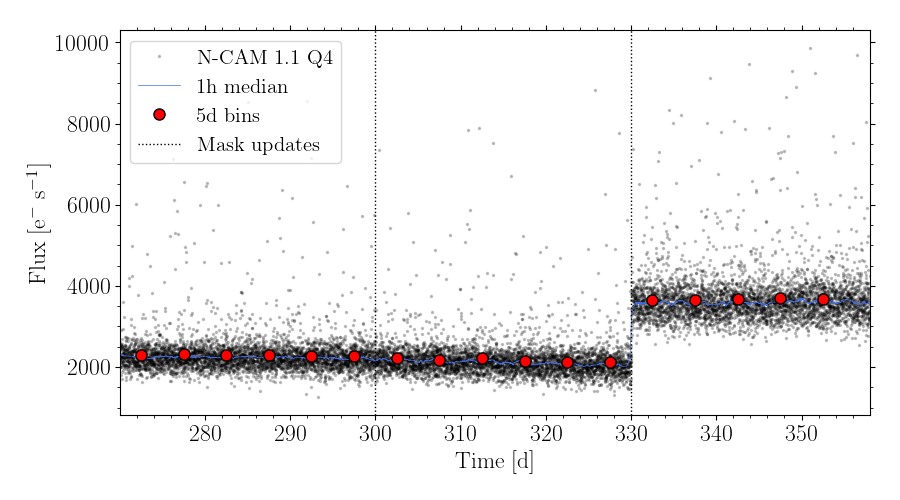

In [183]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


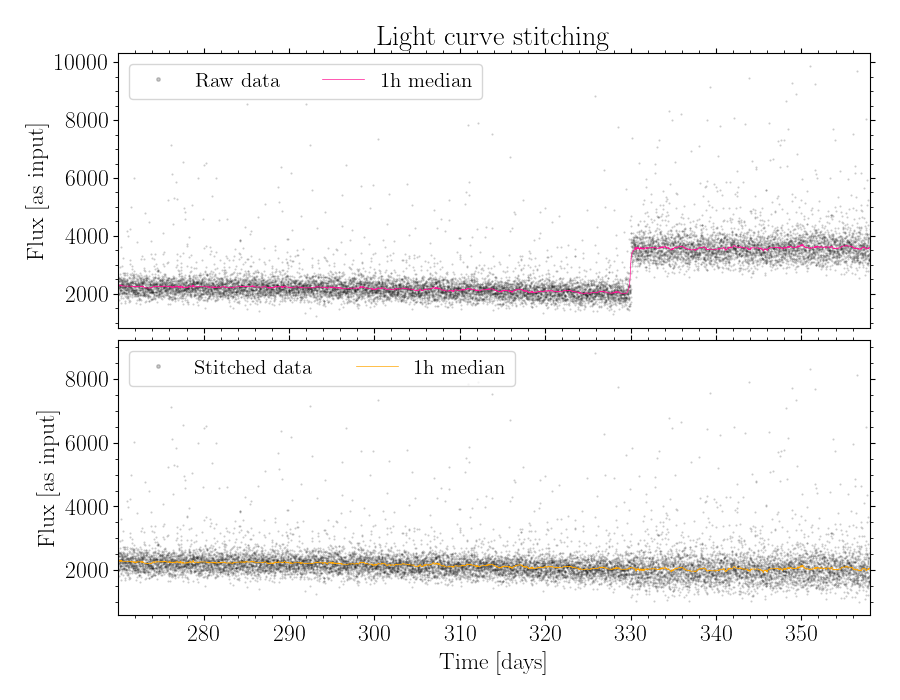

In [188]:
# Stitch light curve
lc.stitch(plot=True);

<IPython.core.display.Javascript object>


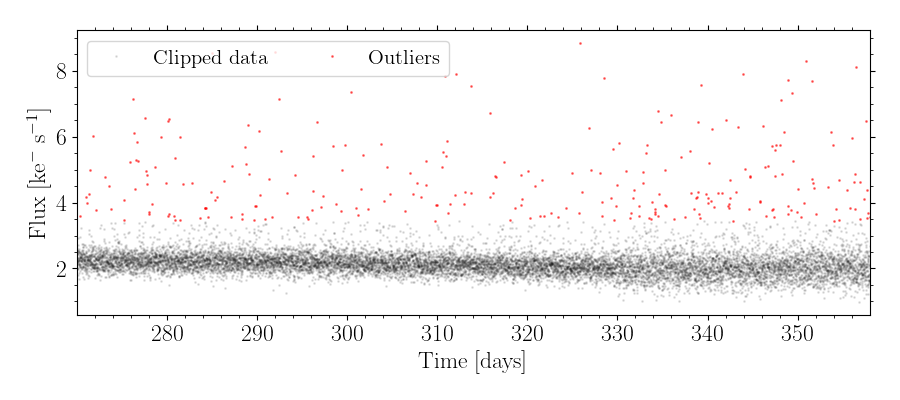

In [191]:
lc.clip(plot=True, column='flux_stitch', low=4, high=4);

## Show all data

In [192]:
# Combine light curves of 17 mag
df1 = pd.DataFrame()
df0 = pd.DataFrame()
for f in filenames:
    lc = LightCurve(f)
    df1['time'] = lc.time(unit='s')
    df1['flux'] = lc.flux(unit='ppt')
    df0 = pd.concat([df0, df1])
    df0 = df0.sort_values(by=['time'])
df = df0

In [193]:
# Combine data
lc_all = LightCurve(df, mode="multi")
lc_all.data()

,time,flux
0,12.50,-383.707866
0,12.50,-202.031342
0,12.50,-398.252559
0,12.50,-287.637674
0,12.50,-424.055069
...,...,...
12671,62034618.75,-119.942363
12671,62034618.75,-13.202836
12671,62034618.75,13.405600
12671,62034618.75,-36.341741


<IPython.core.display.Javascript object>


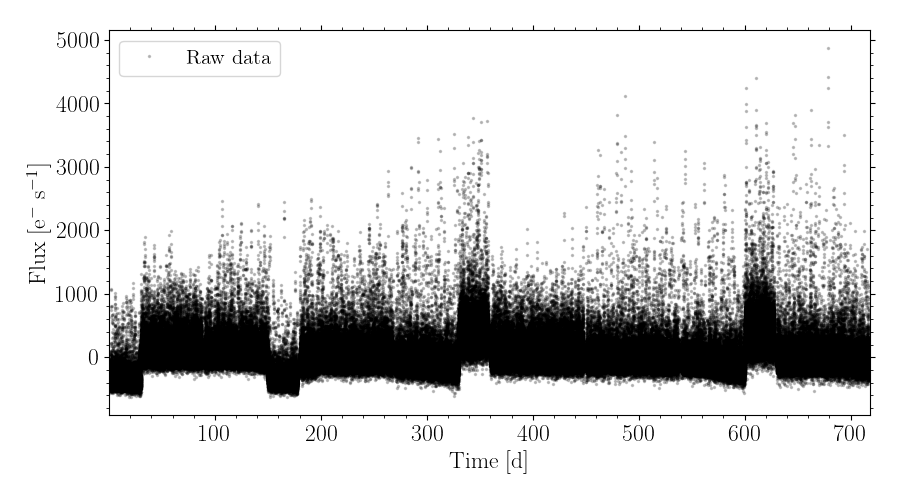

In [194]:
# Plot the simulation, running median, and binned data
fig, ax = lc_all.plot(time_unit="d", binsize=False, median_filter=False);

## Correct light curves

In [204]:
# Combine light curves of 17 mag
df1 = pd.DataFrame()
df0 = pd.DataFrame()
for f in filenames:
    lc0 = LightCurve(f)
    df = lc0.stitch()
    df = lc0.clip(column='flux_stitch', low=4, high=4)
    df1['time'] = lc0.time(unit='d')
    df1['flux'] = df.flux_clip
    df0 = pd.concat([df0, df1])
    df0 = df0.sort_values(by=['time'])
df = df0

In [210]:
# Combine data
lc = LightCurve(df, mode="multi")
lc.stitch()
lc.data()
fig, ax = lc.plot(column='flux_stitch', binsize=False, median_filter=False);

TypeError: plot() got an unexpected keyword argument 'column'

## Remember to remove unpacked files again!

In [33]:
# lcs.remove()